In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,Input, BatchNormalization

In [2]:
#generators

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    directory= '/content/drive/MyDrive/cats dogs/training_set' ,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/cats dogs/test_set' ,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [4]:
#Normalize
def process(image,label):
    image = tf.cast(image/255, tf.float32)
    return image, label

train_ds= train_ds.map(process)
validation_ds = validation_ds.map(process)

In [15]:
#create cnn model
cnn = Sequential()

cnn.add(Input(shape=(256, 256, 3)))

cnn.add(Conv2D(32, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(64, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(128, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Flatten())
cnn.add(Dropout(0.1))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dense(64, activation='relu'))
cnn.add(Dense(1, activation='sigmoid'))


In [16]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [18]:
history =cnn.fit(train_ds, epochs =10, batch_size=32, validation_data= validation_ds, verbose= 1)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 127ms/step - accuracy: 0.6009 - loss: 1.6321 - val_accuracy: 0.4963 - val_loss: 2.7733
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6948 - loss: 0.6058 - val_accuracy: 0.6041 - val_loss: 0.9542
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.7635 - loss: 0.5125 - val_accuracy: 0.7321 - val_loss: 0.5587
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.8296 - loss: 0.3858 - val_accuracy: 0.6935 - val_loss: 0.7138
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.8762 - loss: 0.2846 - val_accuracy: 0.6367 - val_loss: 1.2587
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.8921 - loss: 0.2650 - val_accuracy: 0.7212 - val_loss: 0.9449
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.9307 - loss: 0.1705 - val_accuracy: 0.7410 - val_loss: 0.9169
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.9575 - loss: 0

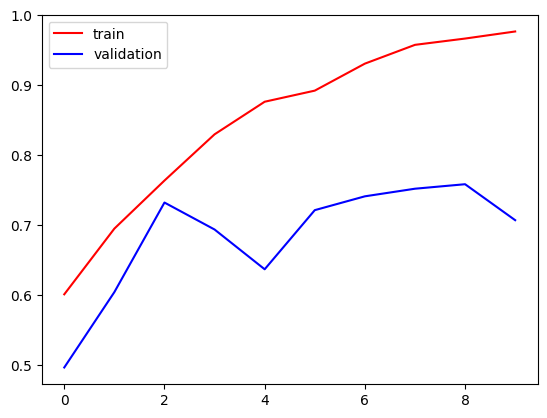

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

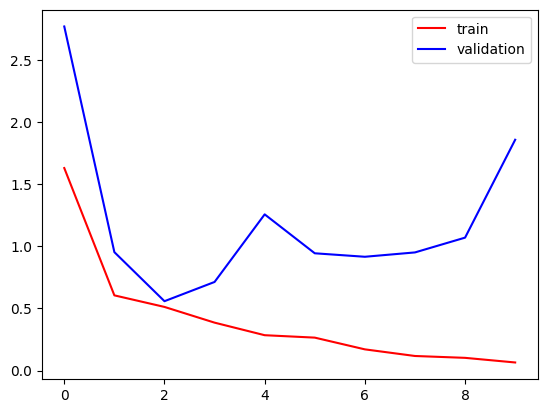

In [20]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()


In [21]:
import joblib
joblib.dump(cnn, 'cnn_model.pkl')

['cnn_model.pkl']